# 01 — EDA

One panel-overview of every equity in the project: all 16 tickers
(Mag7 + quantum + quantum_big + anti) on the same 6 axes — prices, returns,
rolling vol, return histogram, correlation, risk/return. Saves as 6 separate
PDFs into `plots/eda/all_<panel>.pdf` using the project palette.

In [1]:
# === Bootstrap (Colab + local) ===
import sys, os
try:
    import google.colab  # noqa: F401
    get_ipython().system('test -d /content/fys5419 || git clone -q https://github.com/egil10/fys5419.git /content/fys5419')
    get_ipython().run_line_magic('cd', '/content/fys5419/project2/code/notebooks')
except ImportError:
    pass
sys.path.append('..')
from scripts.colab import setup; setup()

# === Project imports ===
from scripts.data    import load_returns, UNIVERSE_BASKETS, UNIVERSE_START, UNIVERSE_END
from scripts.baskets import get as get_basket
from scripts.snp     import SNP

/content/fys5419/project2/code/notebooks
> git -C /content/fys5419 pull
> /usr/bin/python3 -m pip install -q numpy pandas scipy matplotlib yfinance pyarrow
[colab.setup] env=Colab
[colab.setup] cwd  = /content/fys5419/project2/code/notebooks
[colab.setup] path = /content/fys5419/project2/code  (added to sys.path)


In [2]:
# Single 16-equity panel — Mag7 + quantum + quantum_big + anti.
tickers = [t for b in UNIVERSE_BASKETS for t in get_basket(b)]
r = load_returns(tickers, UNIVERSE_START, UNIVERSE_END, cache_name='universe_16')
print(r.prices.head(2))

⟳ cache stale (cache starts 2023-01-03 after requested 2023-01-01); re-fetching
✓ 751 1d obs for ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'IONQ', 'RGTI', 'QBTS', 'QUBT', 'IBM', 'HON', 'ACN', 'NVDA', 'XOM', 'DAL', 'NEM', 'JPM'] (2023-01-03 → 2025-12-30)
✓ cached → data/universe_16.parquet
✓ sample → data/universe_16_sample.csv
Ticker            AAPL        MSFT      GOOGL       AMZN  IONQ   RGTI  QBTS  \
Date                                                                          
2023-01-03  122.982727  233.452805  88.389458  85.820000  3.46  0.728  1.44   
2023-01-04  124.251183  223.240845  87.357986  85.139999  3.61  0.814  1.29   

Ticker      QUBT         IBM         HON         ACN       NVDA        XOM  \
Date                                                                         
2023-01-03  1.52  125.228783  187.384720  255.968262  14.299910  94.790810   
2023-01-04  1.55  126.157700  183.659744  255.096817  14.733451  95.066727   

Ticker            DAL        NEM         JPM  
Da


16 assets, 751 1d obs
Ticker     Ann.Ret   Ann.Vol    Sharpe
AAPL        26.74%    25.46%     1.050
MSFT        24.66%    23.13%     1.066
GOOGL       42.55%    30.24%     1.407
AMZN        33.49%    31.86%     1.051
IONQ        86.43%   100.05%     0.864
RGTI       115.15%   143.41%     0.803
QBTS        97.54%   146.41%     0.666
QUBT        64.62%   139.01%     0.465
IBM         29.15%    23.70%     1.230
HON          1.22%    20.59%     0.059
ACN          1.51%    25.14%     0.060
NVDA        86.48%    49.64%     1.742
XOM          7.75%    22.66%     0.342
DAL         26.27%    38.45%     0.683
NEM         26.92%    37.06%     0.726
JPM         31.81%    23.07%     1.379
✓ saved → plots/eda/all_prices.pdf


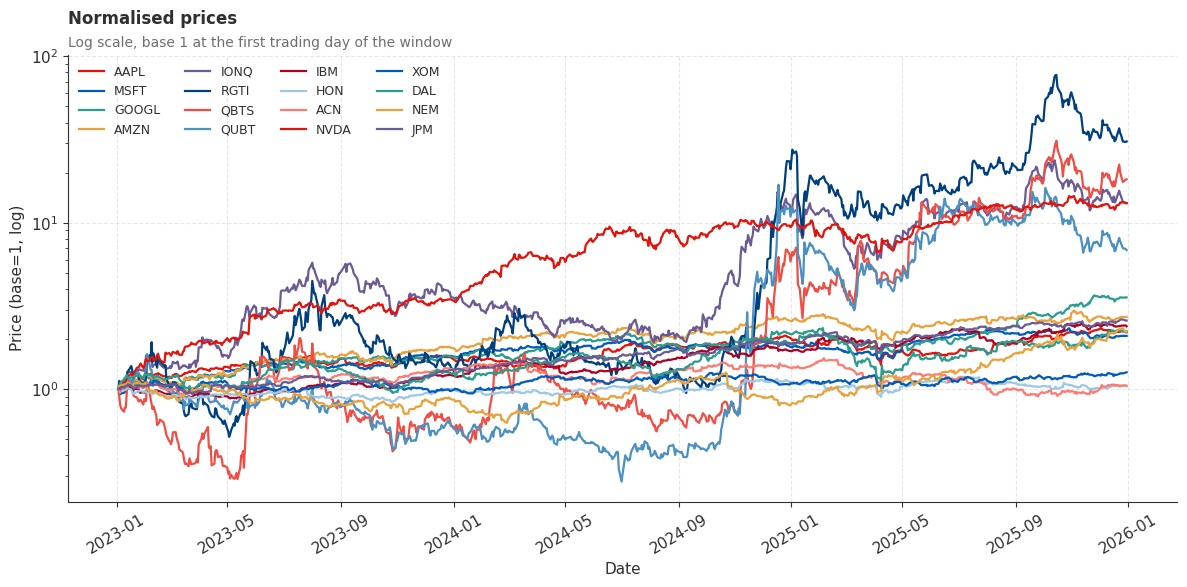

✓ saved → plots/eda/all_returns.pdf


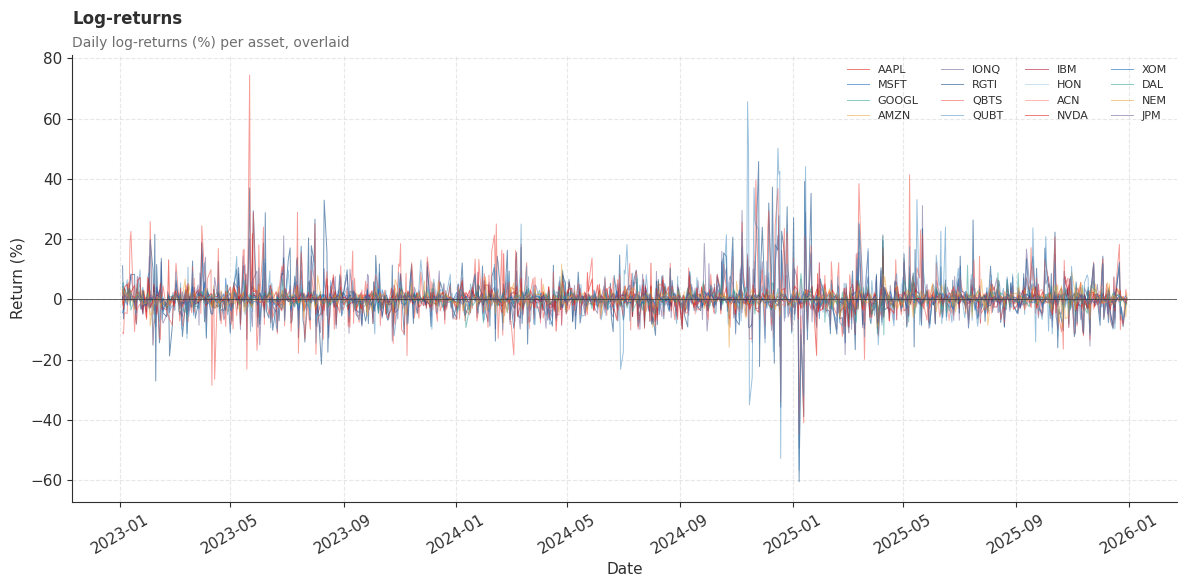

✓ saved → plots/eda/all_rolling_vol.pdf


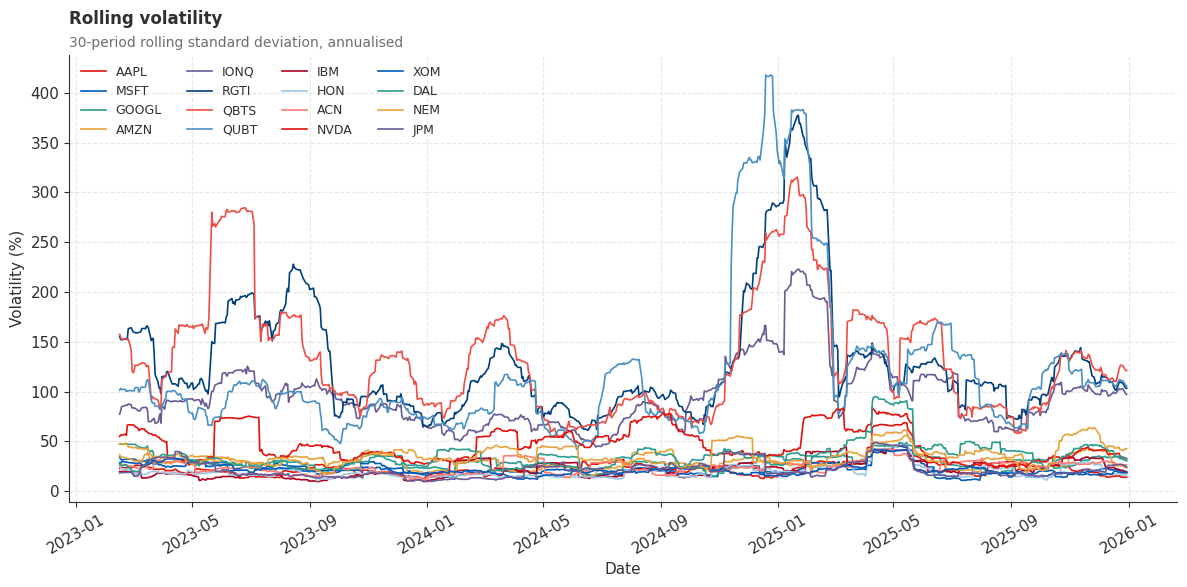

✓ saved → plots/eda/all_histogram.pdf


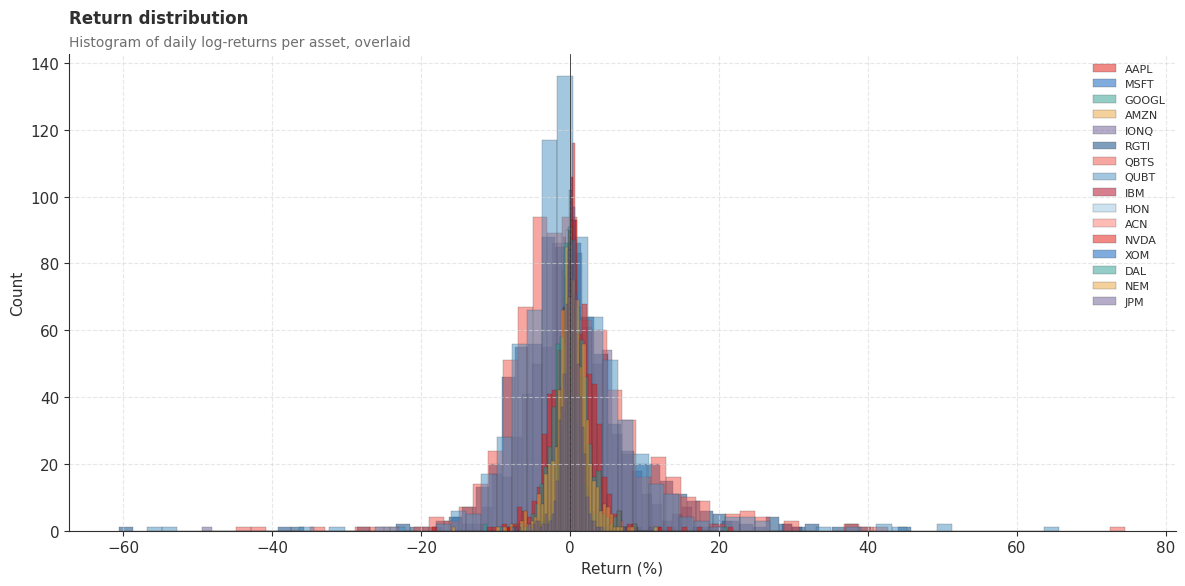

✓ saved → plots/eda/all_correlation.pdf


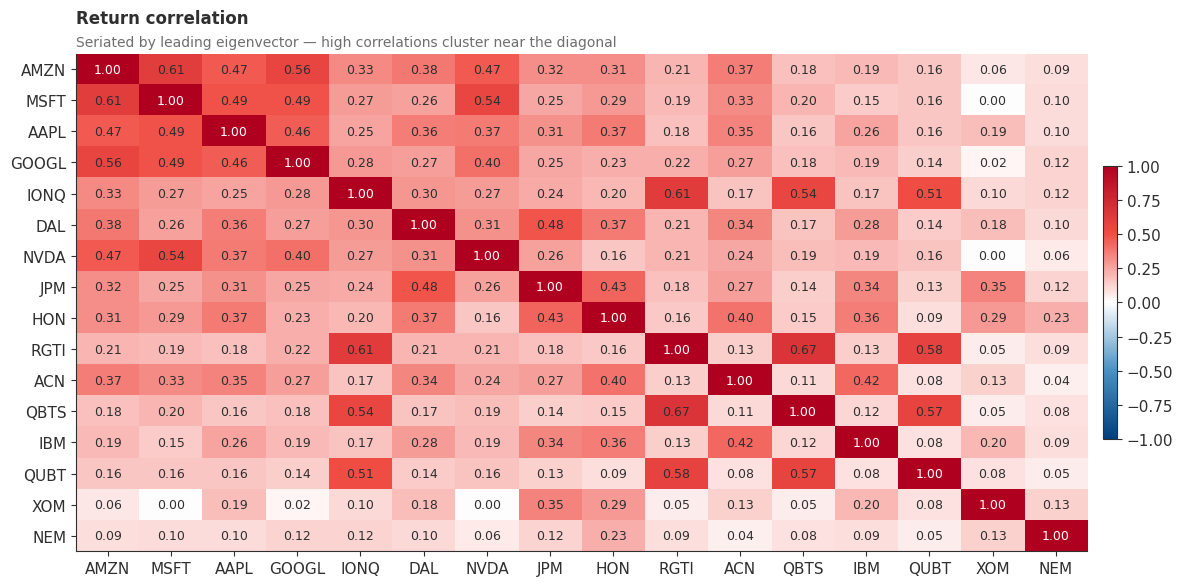

✓ saved → plots/eda/all_risk_return.pdf


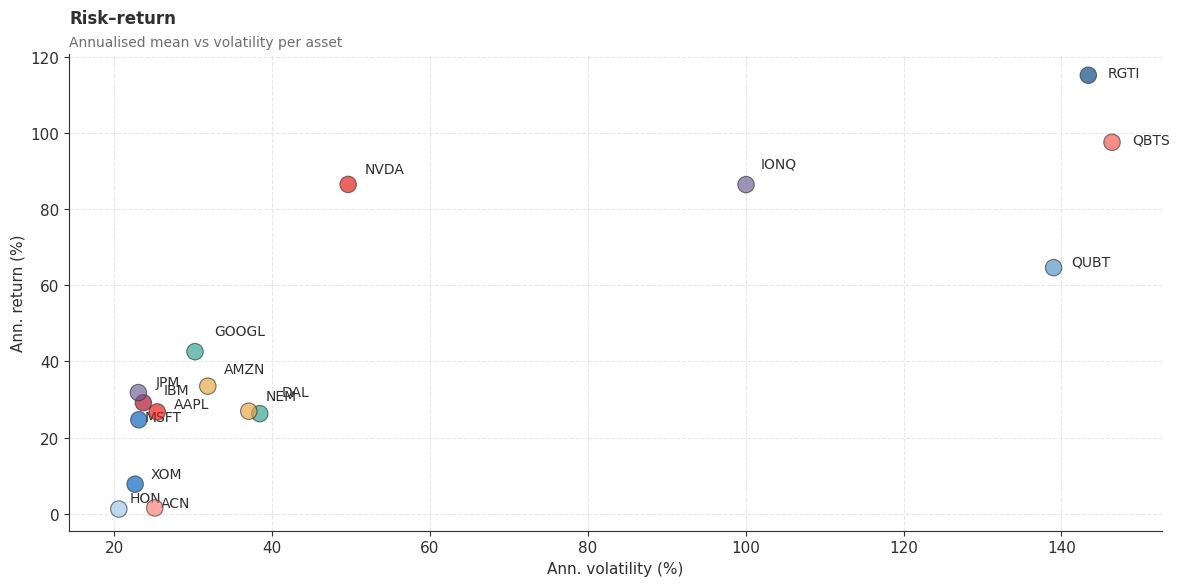

In [3]:
snp = SNP(list(r.tickers), r.prices.index.min(), r.prices.index.max())
snp.prices = r.prices

snp.summary()
snp.plot(save=True, name='all', individual=True, figsize=(12, 6))